# 딥러닝 기초 IV — PyTorch 기초와 MNIST 손글씨 분류

Google Colab / Jupyter 실습용 노트북입니다.

**학습 목표**
- `Dataset` / `DataLoader` 개념 이해
- `transforms`로 데이터 증강(Data Augmentation) 적용
- `nn.Sequential`로 MLP 분류 모델 구축·학습·평가
- 모델은 `nn.Sequential`로만 구성합니다.


## Dataset & DataLoader 핵심 요약

- **Dataset**: 데이터와 라벨을 **한 쌍으로 묶어 관리**하는 객체 (샘플별 전처리 및 데이터 증강 적용).
- **DataLoader**: Dataset을 **미니배치 단위**로 묶어 모델에 학습용으로 공급하는 객체 (`batch_size`, `shuffle` 등의 로직 제어).

### 학습 단위 개념 이해

- **Batch Size**: 한 번에 모델에 입력하는 데이터 샘플 수.
- **Iteration**: 미니배치 1회 학습(가중치 1회 업데이트) 과정을 의미.
- **Epoch**: 전체 데이터를 한 바퀴 모두 학습한 상태.

$$\text{1 Epoch의 Iteration 수} \approx \frac{\text{전체 데이터 개수}}{\text{Batch Size}}$$

## 1. 환경 설정

### 한글 폰트 · 시드 · 디바이스


In [ ]:
import sys
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('device:', device)


Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

## 2. 데이터 준비

### 데이터 증강 (Data Augmentation)
성능 개선을 위해 학습 이미지에 무작위 회전 등을 적용합니다.

- 학습: `RandomRotation` + `ToTensor` + `Normalize`
- 검증/테스트: `ToTensor` + `Normalize` (증강 없음)


In [ ]:
# 코드

### Dataset 생성과 Train / Validation 분할

같은 MNIST 학습셋에 대해
- 증강 transform → 학습용
- 일반 transform → 검증용
인덱스를 나눠 `Subset`으로 분리합니다.


In [ ]:
import torch
from torch.utils.data import Subset
from torchvision import datasets

# 1. 원본 데이터셋 로드 (동일한 6만 개 데이터를 전처리만 다르게 해서 두 번 불러옴)
# [증강 버전] 학습에 사용할 이미지 로테이션 등이 포함된 꽉 찬 데이터셋
train_full_aug = datasets.MNIST(
    root='./data', train=True, download=True, transform=train_transform
)
# [평면 버전] 검증에 사용할 데이터 증강(변형)이 전혀 없는 깨끗한 데이터셋
train_full_plain = datasets.MNIST(
    root='./data', train=True, download=True, transform=eval_transform
)
# [테스트셋] 당연히 데이터 변형이 없는 정돈된 데이터셋[cite: 7]
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=eval_transform
)

# 코드

100%|██████████| 9.91M/9.91M [00:00<00:00, 138MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 48.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 125MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.87MB/s]


train=50000, val=10000, test=10000


## DataLoader 및 Shuffle 핵심 요약

### DataLoader와 배치 개수 계산 (391의 의미)

- **DataLoader의 역할**: 데이터를 미니배치 단위로 쪼개어 모델에 효율적으로 공급합니다.
- **배치 개수 연산 (올림 처리)**: PyTorch는 마지막에 남은 짜투리 데이터도 버리지 않고 하나의 독립된 배치로 처리합니다.
- 조건: 전체 데이터 50,000개 / 배치 크기(Batch Size) 128



$$\text{총 배치 개수} = \lceil \frac{50,000}{128} \rceil = \lceil 390.625 \rceil = \mathbf{391}$$

- **학습 영향**: 1 Epoch 학습 시, 모델의 가중치 업데이트(Iteration)가 총 **391번** 일어납니다.

---

### Shuffle 설정 기준: Train(True) vs Val·Test(False)

- **`train_loader (shuffle=True)`**
- **로컬 미니마 방지**: 데이터 순서에 종속되어 특정 예측에 갇히는 현상을 예방합니다.
- **일반화 능력 극대화**: 매 에포크마다 391개 묶음의 구성을 새롭게 뒤섞어 학습 효과를 높입니다.
- **`val_loader / test_loader (shuffle=False)`**
- **자원 절약**: 평가 단계에서는 굳이 데이터를 섞는 연산을 할 필요가 없습니다.
- **일관성 유지**: 평가 결과의 정량적인 비교 기준과 일관성을 깨뜨리지 않기 위해 순서대로 순회하는 것이 정석입니다.

In [ ]:
# 코드

train batches/epoch ≈ 391


## 증강 샘플 시각화 핵심 요약

### `squeeze().numpy()` 연쇄 동작의 이유

- **`squeeze()`**: PyTorch의 흑백 이미지 차원 `(1, 28, 28)`에서 크기가 1인 채널 차원을 제거하여, Matplotlib이 요구하는 `(28, 28)` 2D 행렬 형태로 맞춰줍니다.
- **`numpy()`**: PyTorch 텐서(Tensor) 구조를 Matplotlib과 완벽히 호환되는 순수 NumPy 배열로 변환하여 에러를 방지합니다.

---

### 정규화 역변환의 필요성

- **문제점**: 정규화(`Normalize`)를 거친 데이터는 표준정규분포 상태(음수 및 1.0 초과 값 존재)이므로, 그대로 시각화하면 색상이 깨지거나 글씨를 알아보기 어렵습니다.
- **해결책**: 인간이 직관적으로 검증할 수 있도록 역변환 수식을 통해 원래의 이미지 스케일로 복원합니다.

$$x_{\text{new}} = x \times \sigma + \mu$$

---

### 증강(Augmentation) 상태 육안 확인

- 시각화된 이미지가 조금씩 좌우로 비뚤어지게 회전된 모습을 통해, 데이터 증강(`RandomRotation`) 툴이 모델 입력 직전에 의도한 대로 잘 작동하고 있는지 최종 검증할 수 있습니다.

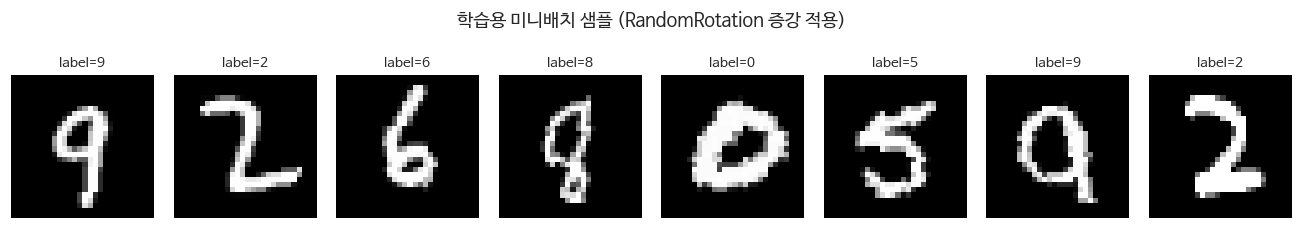

In [ ]:
# 1. train_loader에서 첫 번째 미니배치(배치 크기 128개)를 무작위로 하나 추출합니다.
# iter()로 반복 가능한 객체로 만든 뒤, next()로 첫 번째 묶음을 꺼냅니다.
sample_images, sample_labels = next(iter(train_loader))
n_show = 8 # 시각화하여 화면에 보여줄 이미지 개수 설정

# 2. 1행 8열 구조의 서브플롯(Subplot) 생성
fig, axes = plt.subplots(1, n_show, figsize=(12, 2.2))

for i in range(n_show):
    # [차원 제어] Matplotlib의 imshow는 2D 배열을 받으므로, squeeze()를 통해
    # (1, 28, 28) 형태의 텐서에서 크기가 1인 채널 차원을 제거하여 (28, 28)로 만듭니다.
    # 그 후 PyTorch 텐서를 Matplotlib과 호환되는 NumPy 배열로 변환합니다.
    img = sample_images[i].squeeze().numpy()

    # [시각화 핵심: 정규화 역변환]
    # 앞서 전처리 단계에서 (x - 평균) / 표준편차 로 데이터의 진폭을 깎아놓았습니다.
    # 그대로 그리면 인간의 눈에 너무 어둡거나 왜곡되어 보이므로,
    # 원래의 픽셀 강도(Intensity)로 되돌리기 위해 표준편차(0.3081)를 곱하고 평균(0.1307)을 더해줍니다.
    img = (img * 0.3081) + 0.1307

    # 흑백(cmap='gray') 이미지로 화면에 출력
    axes[i].imshow(img, cmap='gray')

    # 해당 이미지의 실제 정답 라벨을 상단 타이틀로 표시
    axes[i].set_title(f'label={int(sample_labels[i])}', fontsize=9)

    # 그래프의 x축, y축 눈금 선을 제거하여 깔끔하게 이미지 만 출력
    axes[i].axis('off')

# 전체 타일 이미지의 메인 제목 설정
fig.suptitle('학습용 미니배치 샘플 (RandomRotation 증강 적용)', fontsize=12)
fig.tight_layout()
plt.show()

## 모델 구축 (`nn.Sequential`) 핵심 요약

### 기본 아키텍처 및 출력층 수정

* **레이어 구조**: 입력층(28 × 28 = 784차원) $\rightarrow$ 은닉층1(128노드) $\rightarrow$ 은닉층2(64노드) $\rightarrow$ 출력층(10노드, 숫자 0~9 분류).
* **출력층 정정**: `nn.NLLLoss()`는 입력값으로 일반 확률이 아닌 로그 확률을 요구합니다. 따라서 모델의 마지막 레이어는 일반 `nn.Softmax`가 아닌 `nn.LogSoftmax(dim=1)`를 사용해야 수학적 왜곡 없이 정상적으로 학습됩니다.

---

### 손실 함수(Loss) 매칭 규칙

* **`nn.LogSoftmax()` + `nn.NLLLoss()` (정석 연산)**
* 확률에 로그($\log$)를 먼저 취해 수치적 안정성(Underflow 방지)과 연산 효율성을 확보한 후 오차를 계산하는 전통적인 결합 방식입니다.


* **`nn.CrossEntropyLoss()` (통합 연산)**
* 내부적으로 `LogSoftmax`와 `NLLLoss`가 합쳐져 있으므로, 모델 끝단에 아무것도 처리하지 않은 생짜 로짓(Logits)을 그대로 입력해야 합니다.


* **주의 (중복 에러)**
* 모델 끝단에 `nn.Softmax`를 적용하고 손실 함수로 `nn.CrossEntropyLoss`를 지정하면, 소프트맥스가 중복 적용되어 확률 분포가 왜곡되고 가중치 업데이트가 불가능해집니다.



---

### 수강생 실습 가이드

* **미션**: 제공된 주석 블록 내에 `nn.Linear`, `nn.Dropout`, `nn.BatchNorm1d` 등의 레이어를 자유롭게 삽입·조합하여 베이스라인 모델의 성능을 뛰어넘는 구조를 설계합니다.

In [ ]:
# 코드

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
  (6): Softmax(dim=1)
)


## 모델 학습 핵심 요약

### 1) 훈련 및 검증 단계 핵심 설정

- **훈련 단계 (Train Phase)**
- **`model.train()`**: 모델을 학습 모드로 전환하여 드롭아웃(Dropout) 등 학습용 레이어의 무작위 연산을 활성화합니다.
- **`optimizer.zero_grad()`**: 이전 미니배치의 잔여 기울기(Gradient)를 깨끗이 비워 오작동을 방지합니다.
- **순전파 및 역전파**: 모델 예측 후 `loss.backward()`로 그라디언트를 계산하고, `optimizer.step()`으로 가중치를 업데이트합니다.
- **검증 단계 (Validation Phase)**
- **`model.eval()`**: 모델을 평가 모드로 전환하여 드롭아웃 등의 무작위성 기능을 비활성화합니다.
- **`torch.no_grad()`**: 기울기 계산 그래프 생략을 통해 메모리를 절약하고 추론 속도를 끌어올립니다.
- **모니터링**: 독립된 검증 손실(`val_loss`)을 확인하여 모델의 과적합(Overfitting) 여부를 진단합니다.



---

### 2) 코드 속 핵심 엔지니어링 디테일

- **`outputs.clamp_min(1e-8)`의 안전장치**
- 확률이 완벽한 $0$이 되었을 때 로그 연산(`log(0)`)으로 인해 $-\infty$(마이너스 무한대)가 발생하여 그라디언트가 터지는(**NaN 오류**) 현상을 방지합니다. 최솟값을 미세한 양수($10^{-8}$)로 강제 제한하는 예외 처리입니다.

- **`images.size(0)`를 곱해주는 이유**
- 마지막 짜투리 배치는 설정한 배치 크기보다 작을 수 있습니다. 정확한 전체 평균 손실을 구하기 위해, 배치별 평균 오차에 실제 샘플 수(`images.size(0)`)를 곱해 누적한 뒤 최종 전체 샘플 수로 나누는 **가중 평균 방식**을 사용합니다.

In [ ]:
# 코드

Epoch 01/8 | train_loss=0.4078 | val_loss=0.2059
Epoch 02/8 | train_loss=0.1831 | val_loss=0.1553
Epoch 03/8 | train_loss=0.1321 | val_loss=0.1172
Epoch 04/8 | train_loss=0.1128 | val_loss=0.0998
Epoch 05/8 | train_loss=0.0962 | val_loss=0.0953
Epoch 06/8 | train_loss=0.0855 | val_loss=0.0967
Epoch 07/8 | train_loss=0.0802 | val_loss=0.0910
Epoch 08/8 | train_loss=0.0707 | val_loss=0.0818


## 6. 학습 곡선 시각화

### Direct Labeling
- `ax.legend()` 범례 상자는 사용하지 않습니다.
- 곡선이 끝나는 지점 **우측**에 이름을 직접 붙입니다.
- 글자가 잘리지 않도록 `xlim` 여백을 넓힙니다.


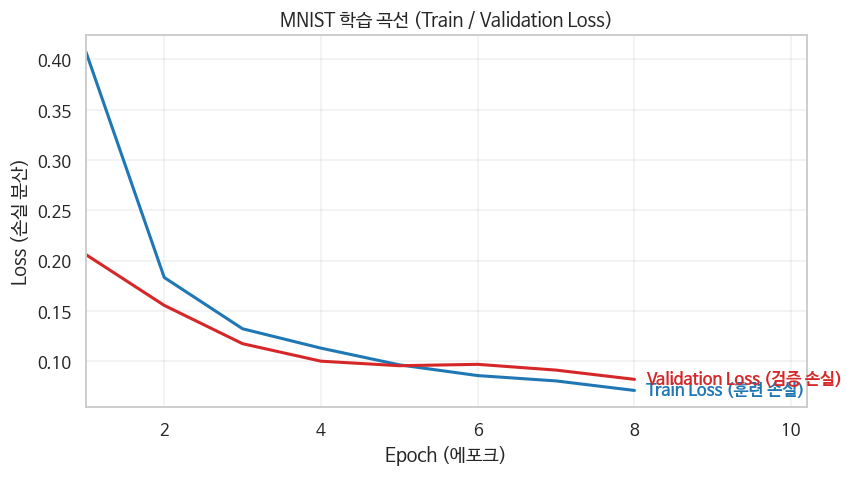

In [ ]:
# 1. x축에 표시할 에포크 리스트 생성 (1부터 시작하여 직관적인 시각화 유도)
epochs_x = list(range(1, EPOCHS + 1))

# 2. 시각화를 위한 플롯 공간(1행 1열 구조) 생성
fig, ax = plt.subplots(figsize=(8, 4.5))

# 3. 훈련 손실(Train Loss) 및 검증 손실(Validation Loss) 선 그래프 그리기
# - 가독성을 위해 명확하게 대비되는 헥사코드 색상(#1f77b4: 블루, #d62728: 레드)과 선 두께(linewidth=2)를 지정합니다.
ax.plot(epochs_x, train_losses, color='#1f77b4', linewidth=2)
ax.plot(epochs_x, val_losses, color='#d62728', linewidth=2)

# ================================================================= #
# [핵심 기술: 직접 레이블링 (Direct Labeling)]
# - ax.legend()를 쓰면 차트 영역의 데이터를 가리거나 시선이 분산되는 단점이 있습니다.
# - 마지막 에포크 포인트(epochs_x[-1])에서 우측으로 살짝 오프셋(+0.15)을 준 뒤,
#   해당 선과 완전히 일치하는 색상 및 굵은 글씨(bold)로 레이블을 텍스트로 배치합니다.
# ================================================================= #
ax.text(
    epochs_x[-1] + 0.15, train_losses[-1], 'Train Loss (훈련 손실)',
    color='#1f77b4', va='center', fontsize=11, fontweight='bold',
)
ax.text(
    epochs_x[-1] + 0.15, val_losses[-1], 'Validation Loss (검증 손실)',
    color='#d62728', va='center', fontsize=11, fontweight='bold',
)

# 4. [텍스트 충돌/잘림 방지]
# - 데이터는 8번(EPOCHS) 에포크까지 있지만, x축 우측 범위를 2.2만큼 더 확장(EPOCHS + 2.2)합니다.
# - 이 여백 처리를 통해 방금 배치한 텍스트 레이블이 그래프 바깥 경계선에 걸려 잘려 나가는 현상을 차단합니다.
ax.set_xlim(1, EPOCHS + 2.2)

# 5. 축 이름, 타이틀 및 스타일링 레이아웃 정리
ax.set_xlabel('Epoch (에포크)')
ax.set_ylabel('Loss (손실 분산)')
ax.set_title('MNIST 학습 곡선 (Train / Validation Loss)')

# 그래프 내부에 은은한 격자 무늬(투명도 alpha=0.3)를 추가하여 정확한 수치 가독성을 높입니다.
ax.grid(alpha=0.3)

# 요소들의 배치 레이아웃을 최적화한 후 차트를 최종 출력합니다.
fig.tight_layout()
plt.show()

## 7. 평가와 예측

### 테스트 정확도


In [ ]:
# 코드

Test Accuracy: 97.73% (9773/10000)


### 테스트 샘플 예측 시각화


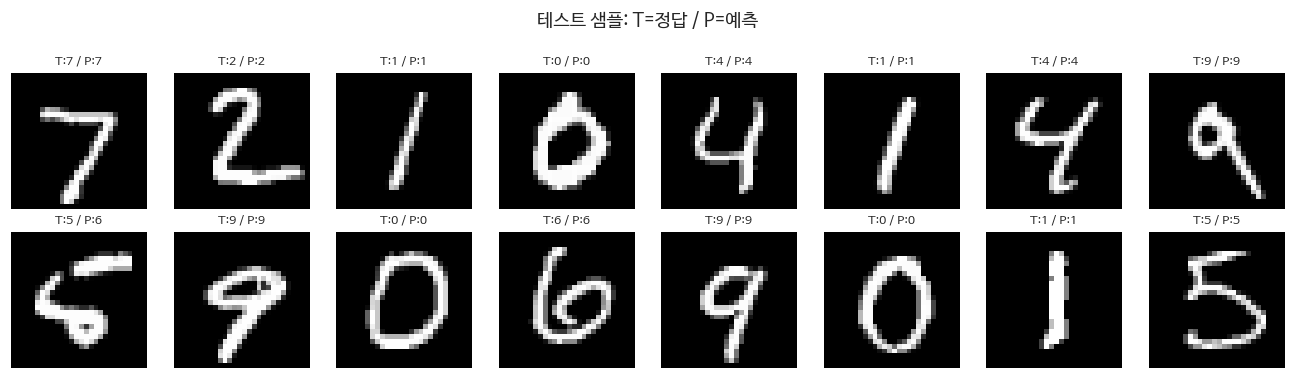

In [ ]:
# 코드

## 8. 정리

| 단계 | 핵심 |
|------|------|
| Dataset | 데이터+라벨, transform으로 전처리/증강 |
| DataLoader | 미니배치 공급 |
| Augmentation | `RandomRotation` 등 |
| Model | `nn.Sequential` + 수강생 실습 영역 |
| 시각화 | `fig, ax` + Direct Labeling |

